In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib import rcParams
import matplotlib.transforms as mtransforms
import numpy as np
from matplotlib.ticker import NullFormatter
import matplotlib.font_manager as fm

def on_press(event):
    print("my position:", event.button, event.xdata, event.ydata)

fontsize = 8
fonttype = 'sans-serif'
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['figure.dpi'] = 150

if (fonttype == 'serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    mpl.rc('text.latex', preamble=r'\usepackage{amsmath, newtxtext, newtxmath}')
    plt.rcParams['font.family'] = 'serif'
elif (fonttype == 'sans-serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    plt.rcParams['font.family'] = 'sans-serif'
    latex_preamble = r"""
    \usepackage[T1]{fontenc}
    \usepackage{bm, amsmath, sansmathfonts}    

    \makeatletter
    \AtBeginDocument{
        \DeclareSymbolFont{sansextrabold}{T1}{cmss}{bx}{n}
        \DeclareMathSymbol{+}{\mathbin}{sansextrabold}{"2B}
        \DeclareMathSymbol{=}{\mathrel}{sansextrabold}{"3D}
        \DeclareMathSymbol{<}{\mathrel}{sansextrabold}{"3C}
        \DeclareMathSymbol{>}{\mathrel}{sansextrabold}{"3E}
        \DeclareMathSymbol{|}{\mathord}{sansextrabold}{"7C}
        \DeclareMathSymbol{/}{\mathord}{sansextrabold}{"2F}

        \DeclareSymbolFont{boldsanssymbols}{OMS}{cmsssy}{b}{n}
        \DeclareMathSymbol{-}{\mathbin}{boldsanssymbols}{"00}
        \DeclareMathSymbol{\times}{\mathbin}{boldsanssymbols}{"02}


        \DeclareMathSymbol{\oplus}{\mathbin}{boldsanssymbols}{"08}
        \DeclareMathSymbol{\otimes}{\mathbin}{boldsanssymbols}{"0A}
        \DeclareMathSymbol{\approx}{\mathrel}{boldsanssymbols}{"19}
        \DeclareMathSymbol{\perp}{\mathrel}{boldsanssymbols}{"3F}
        \DeclareMathSymbol{\sim}{\mathrel}{boldsanssymbols}{"18}
        \DeclareMathSymbol{\to}{\mathrel}{boldsanssymbols}{"21}
        \DeclareMathSymbol{\leftarrow}{\mathrel}{boldsanssymbols}{"20}
        \DeclareMathSymbol{\in}{\mathrel}{boldsanssymbols}{"32}

        \let\original@le\le
        \let\original@ge\ge
        \let\original@langle\langle
        \let\original@rangle\rangle

        \renewcommand{\le}{\bm{\original@le}}
        \renewcommand{\ge}{\bm{\original@ge}}
        \renewcommand{\langle}{\bm{\original@langle}}
        \renewcommand{\rangle}{\bm{\original@rangle}}
        \renewcommand{\|}{|\hspace{-1pt}|}
    }
    \makeatother

    \newcommand{\p}{\partial}
    \newcommand{\T}{^{\mathrm{T}}}
    \renewcommand{\vec}[1]{\boldsymbol{#1}}
    \newcommand{\bn}{\vec{\nabla}}
    \newcommand\ii{\mathrm{i}}
    \newcommand\ee{\mathrm{e}}
    \newcommand{\widebar}[1]{\mskip.5\thinmuskip\overline{\mskip-.5\thinmuskip {#1} \mskip-.5\thinmuskip}\mskip.5\thinmuskip}
    \newcommand{\ket}[1]{| #1 \rangle}
    \newcommand{\bra}[1]{\langle #1 |}
    """
    mpl.rc('text.latex', preamble=latex_preamble)

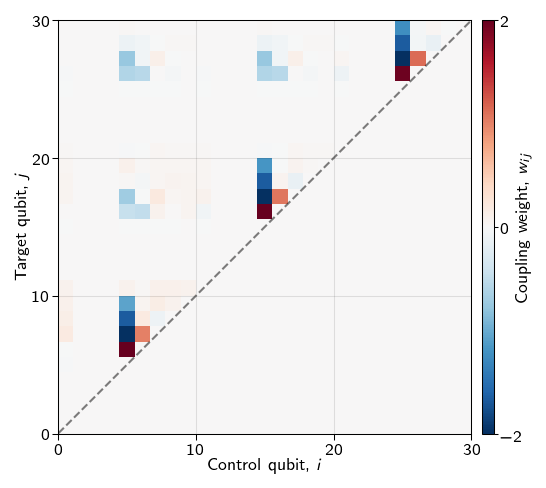

In [50]:
weights_matrix = np.load(fr'data/3D/weights_matrix.npy')
nx, ny, nz = 9, 9, 9

fig_width = 18/2.54
fig_height = 18/2.54
fig = plt.figure(figsize=(fig_width, fig_height))

ax_width = 7/2.54 / fig_width
ax_height = 7/2.54 / fig_height
cbar_length = ax_height
cbar_width = 0.2/2.54 / fig_width

# 
ax = fig.add_axes([0, 0, ax_width, ax_height])
ax.pcolormesh(weights_matrix, cmap='RdBu_r', vmin=-2, vmax=2)
ax.plot(np.linspace(-1, 30, 100), np.linspace(-1, 30, 100), linewidth=1, linestyle='--', color='k', alpha=0.5)

ax.grid(color='k', linestyle='-', linewidth=0.5, alpha=0.1)

plt.xlim(0, 27) 
plt.ylim(0, 27)
plt.xlabel(r'Control qubit, $i$', labelpad=0, size=fontsize)
plt.ylabel(r'Target qubit, $j$', labelpad=1, size=fontsize)
ax.set_xticks([0, 9, 18, 27])
ax.set_xticklabels([r'$0$', r'$10$', r'$20$', r'$30$'])
ax.set_yticks([0, 9, 18, 27])
ax.set_yticklabels([r'$0$', r'$10$', r'$20$', r'$30$'])
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(axis='x', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1.5)
ax.tick_params(axis='y', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1)
ax.tick_params(which='minor', direction='out', top=False, right=False, length=1.5, width=0.5)

cax = fig.add_axes([ax_width+0.01, 0, cbar_width, cbar_length])
cbar = plt.colorbar(mpl.cm.ScalarMappable(mpl.colors.Normalize(vmin=0, vmax=1), 'RdBu_r'), ax=ax, cax=cax, orientation='vertical', ticks=[0, 0.5, 1], location='right')
cbar.set_ticklabels(['$-2$', '$0$', '$2$'])
cax.text(3.5, 0.5, r'Coupling weight, $w_{ij}$', ha='center', va='center', rotation=90)
cbar.ax.tick_params(length=2, width=0.5, labelsize=fontsize, pad=1)
cbar.outline.set_linewidth(0.5)

plt.savefig(fr'figures/weights_matrix.pdf', transparent=True, orientation='portrait', format='pdf', bbox_inches='tight')